In [1]:
# DEPENDENCIES
import numpy as np
import xarray as xr
import pandas as pd
import glob
import multiprocessing
import tqdm
import sys
import os
import pathlib
sys.path.append('/home/e/ermis/forecast-based-attribution-ICP/src')
from perturb import preproc,apply
from aux import definitions
import rioxarray as rio
from cdo import Cdo
cdo = Cdo(tempdir='{}tmp'.format(definitions.AOPP_BASE_PATH))
import gzip

## get my stats functions
from mystatsfunctions import OLSE,LMoments
from moarpalettes import get_palette
from matplotlib import pyplot as plt
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
from cartopy import crs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature
import seaborn as sn

## get fair
from fair import *

In [2]:
MON=6
awi = preproc.get_AWI()

Integrating 3 scenarios, 1 gas cycle parameter sets, 1 thermal response parameter sets, over ['bc', 'bc|aci', 'bc|bc_on_snow', 'c2f6', 'c3f8', 'c4f10', 'c5f12', 'c6f14', 'c7f16', 'c8f18', 'c_c4f8', 'carbon_dioxide', 'carbon_tetrachloride', 'carbon_tetrachloride|o3', 'cf4', 'cfc11', 'cfc113', 'cfc113|o3', 'cfc114', 'cfc114|o3', 'cfc115', 'cfc115|o3', 'cfc11|o3', 'cfc12', 'cfc12|o3', 'ch2cl2', 'ch2cl2|o3', 'ch3ccl3', 'ch3ccl3|o3', 'chcl3', 'chcl3|o3', 'co', 'co|o3', 'halon1202', 'halon1202|o3', 'halon1211', 'halon1211|o3', 'halon1301', 'halon1301|o3', 'halon2402', 'halon2402|o3', 'hcfc141b', 'hcfc141b|o3', 'hcfc142b', 'hcfc142b|o3', 'hcfc22', 'hcfc22|o3', 'hfc125', 'hfc134a', 'hfc143a', 'hfc152a', 'hfc227ea', 'hfc23', 'hfc236fa', 'hfc245fa', 'hfc32', 'hfc365mfc', 'hfc4310mee', 'methane', 'methane|strat_h2o', 'methane|o3', 'methyl_bromide', 'methyl_bromide|o3', 'methyl_chloride', 'methyl_chloride|o3', 'nf3', 'nh3', 'nitrous_oxide', 'nitrous_oxide|o3', 'nmvoc', 'nmvoc|o3', 'nox', 'nox_avi'

/home/e/ermis/FAIR-2.0.0-alpha/fair/fair_runner.py:127: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0).apply(pd.to_numeric)
100%|██████████| 274/274 [00:00<00:00, 3743.17 timestep/s]


In [3]:
definitions.AOPP_BASE_PATH

'/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/'

# Check raw perturbations

In [4]:
sst_pattern = xr.open_dataarray(cdo.remapbil('r720x360',input='{}output/tmp/t2d_{:02d}_raw.nc'.format(definitions.AOPP_BASE_PATH,MON))).squeeze()
# sst_pattern = xr.open_dataarray(cdo.remapbil('r720x360',input='{}output/tmp/t2d_12_raw.nc'.format(definitions.AOPP_BASE_PATH))).squeeze()

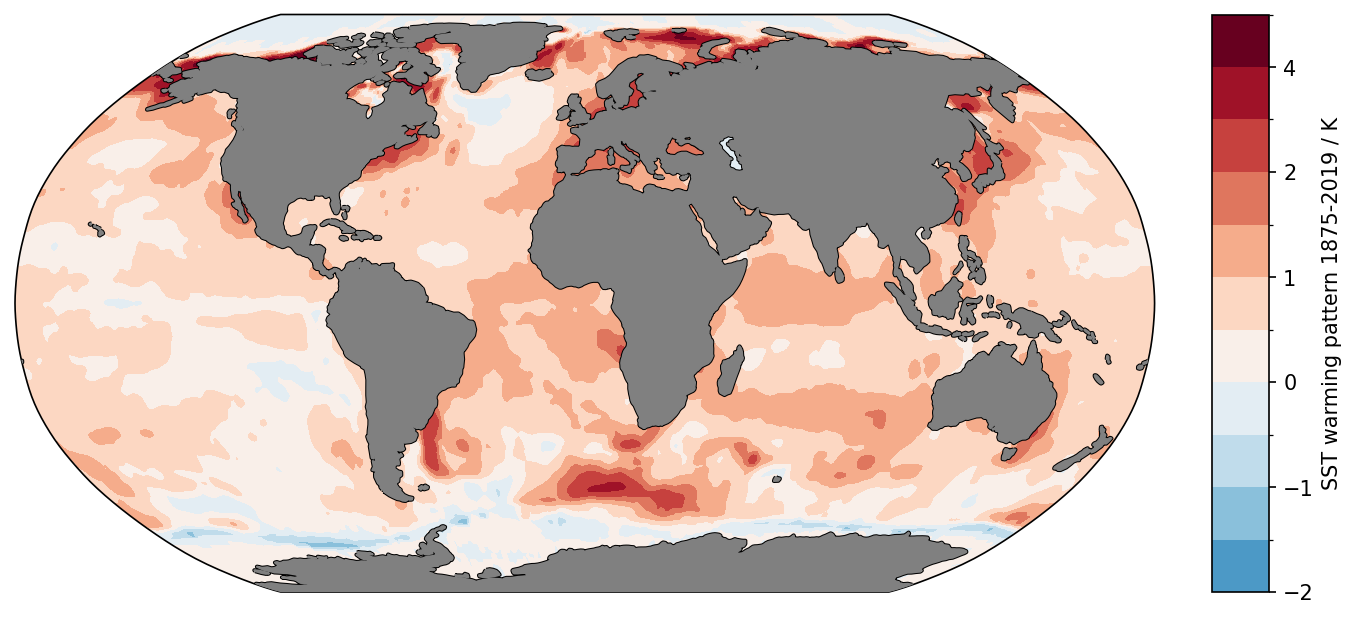

In [5]:
gwarm_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('trunc({n},{a:.2f},{b:.2f})'.format(n=matplotlib.cm.RdBu_r.name, a=0.5-2/7, b=1),
                                                                 matplotlib.cm.RdBu_r(np.linspace(0.5-2/7, 1, 256)))

fig,ax = plt.subplots(figsize=(10,5),subplot_kw=dict(projection=crs.Robinson()))

p=sst_pattern.plot.contourf(ax=ax,cmap=gwarm_cmap,
                            levels=[-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,3,4,6],
                            transform=crs.PlateCarree(),
                            add_colorbar=False)

axins = inset_axes(ax, width="5%",height="100%",loc='lower left',
                   bbox_to_anchor=(1.05, 0.00, 1, 1),
                   bbox_transform=ax.transAxes,borderpad=0)

cbar=plt.colorbar(p,cax=axins)
axins.set_ylabel('SST warming pattern 1875-2019 / K')

ax.add_feature(cfeature.LAND,color='grey',zorder=3)
ax.coastlines(lw=2)

fig.dpi=150

In [6]:
t3d_zonmean = xr.open_dataarray(cdo.zonmean(input='-remapbil,r360x180 -ifthen -selvar,tmask {0}source/ancil/mesh_mask.nc {0}output/tmp/t3d_{1:02d}_hybr.nc'.format(definitions.AOPP_BASE_PATH,MON)))


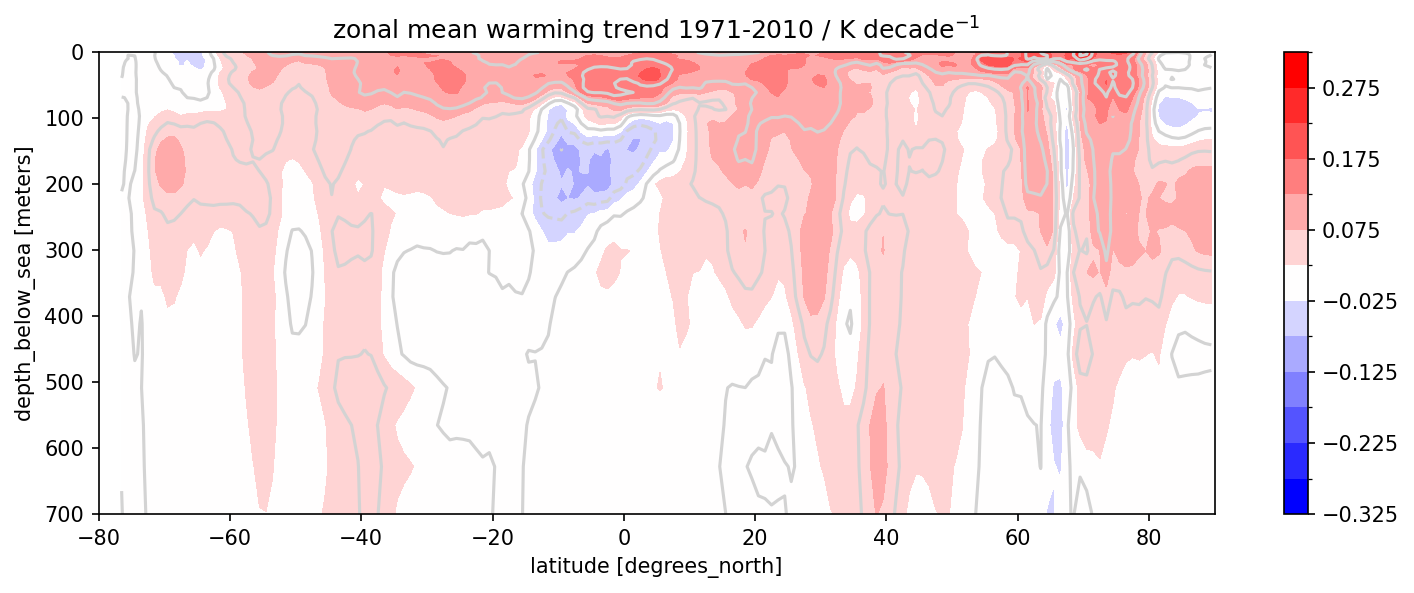

In [7]:
## set scale factor to convert restart pertubration to AR5F3.1 units
scale_factor = (awi.loc[2010]-awi.loc[1971].mean()) / (awi.loc[2019]-awi.loc[1850:1900].mean()) / 4

p=(t3d_zonmean*scale_factor).squeeze().plot.contourf(levels=np.linspace(-0.325,0.325,14),extend='neither',cmap='bwr',add_colorbar=True,figsize=(12,4))
(t3d_zonmean*scale_factor).squeeze().plot.contour(levels=np.linspace(-0.3,0.3,13),colors='lightgrey',add_colorbar=False)

plt.ylim(700,0)
plt.xlim(-80,90)
plt.title('zonal mean warming trend 1971-2010 / K decade$^{-1}$')
plt.gcf().dpi=150

In [8]:
sic_remap = xr.open_dataset(cdo.remapbil('r720x360',input='-ifthen -sellevidx,1 -selvar,tmask {0}source/ancil/mesh_mask.nc {0}output/tmp/sic_{1:02d}_raw.nc'.format(definitions.AOPP_BASE_PATH,MON)))

/tmp/user/27529/ipykernel_329026/2531407781.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sic_trend_cmap = matplotlib.cm.get_cmap('RdBu').copy()


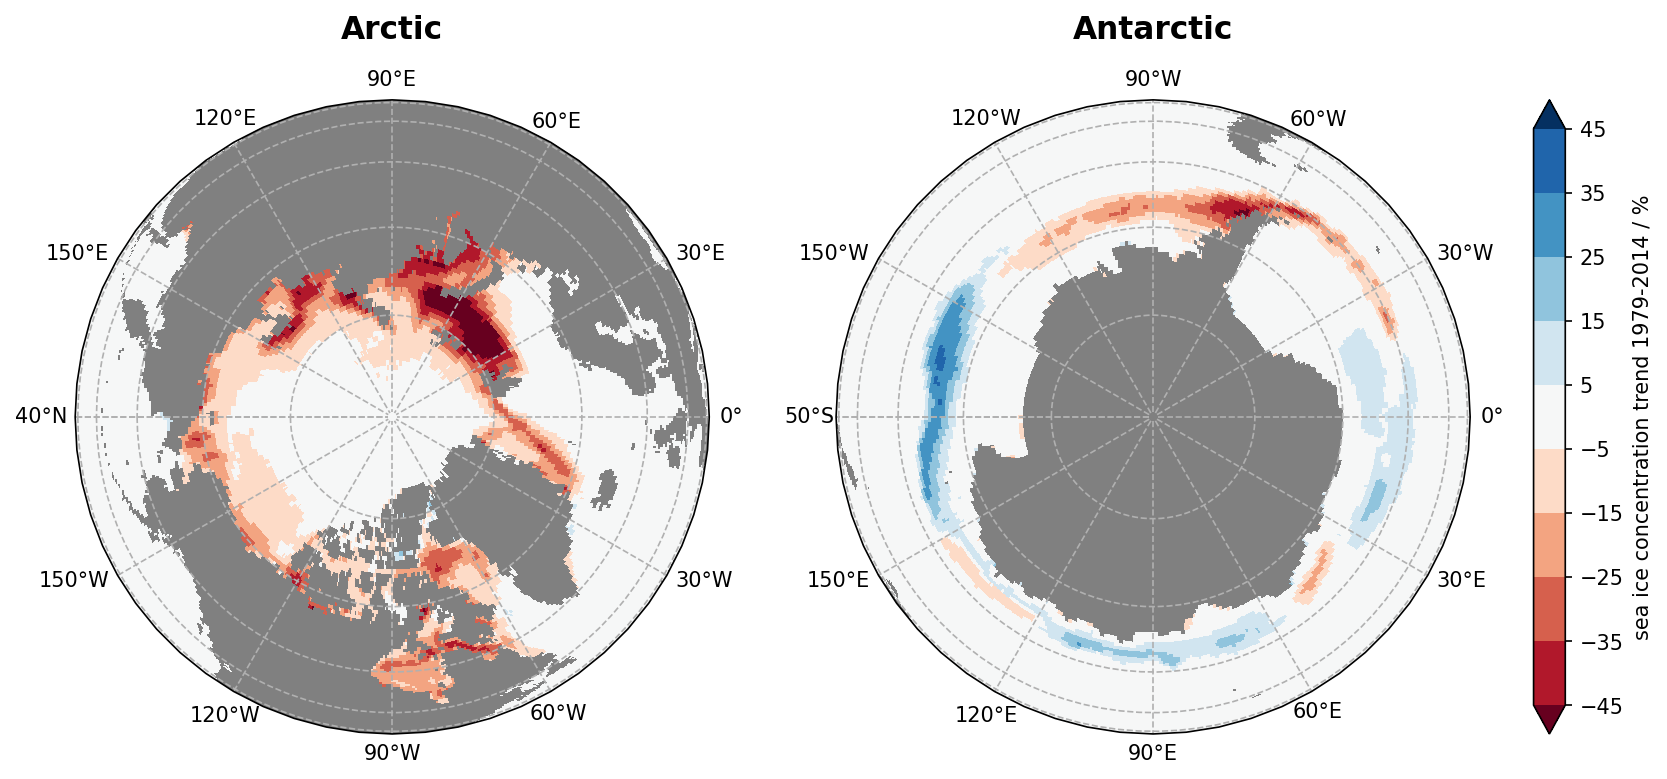

In [9]:
sic_trend_cmap = matplotlib.cm.get_cmap('RdBu').copy()
sic_trend_cmap.set_bad(color='grey')

scale_factor = 100 * (awi.loc[2014]-awi.loc[1979].mean()) / (awi.loc[2019]-awi.loc[1850:1900].mean())

fig = plt.figure(figsize=(12,6))
gs = fig.add_gridspec(1,2)

ax = [fig.add_subplot(gs[i],projection=crs.NearsidePerspective(central_longitude=-90,central_latitude=x,satellite_height=5000000)) for i,x in enumerate([90,-90])]

p=(sic_remap*scale_factor).ileadfra.plot(ax=ax[0],transform=crs.PlateCarree(),add_colorbar=False,levels=np.linspace(-45,45,10),cmap=sic_trend_cmap,extend='both')
p=(sic_remap*scale_factor).ileadfra.plot(ax=ax[1],transform=crs.PlateCarree(),add_colorbar=False,levels=np.linspace(-45,45,10),cmap=sic_trend_cmap,extend='both')

axins = inset_axes(ax[1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.1, 0.00, 1, 1),bbox_transform=ax[1].transAxes,borderpad=0)
cbar=plt.colorbar(p,cax=axins)
axins.set_ylabel('sea ice concentration trend 1979-2014 / %')

ax[0].set_title('Arctic',pad=15,fontsize=15,fontweight='bold')
ax[1].set_title('Antarctic',pad=15,fontsize=15,fontweight='bold')

ax[0].gridlines(draw_labels=True,xlocs=np.arange(-180,181,30),linestyle='--')
ax[1].gridlines(draw_labels=True,xlocs=np.arange(-180,181,30),linestyle='--')

fig.dpi=150;

In [10]:
sit_remap = xr.open_dataset(cdo.remapbil('r720x360',input='-ifthen -sellevidx,1 -selvar,tmask {0}source/ancil/mesh_mask.nc {0}output/tmp/sit_{1:02d}_raw.nc'.format(definitions.AOPP_BASE_PATH,MON)))


/tmp/user/27529/ipykernel_329026/1064479606.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sit_trend_cmap = matplotlib.cm.get_cmap('bwr').copy()


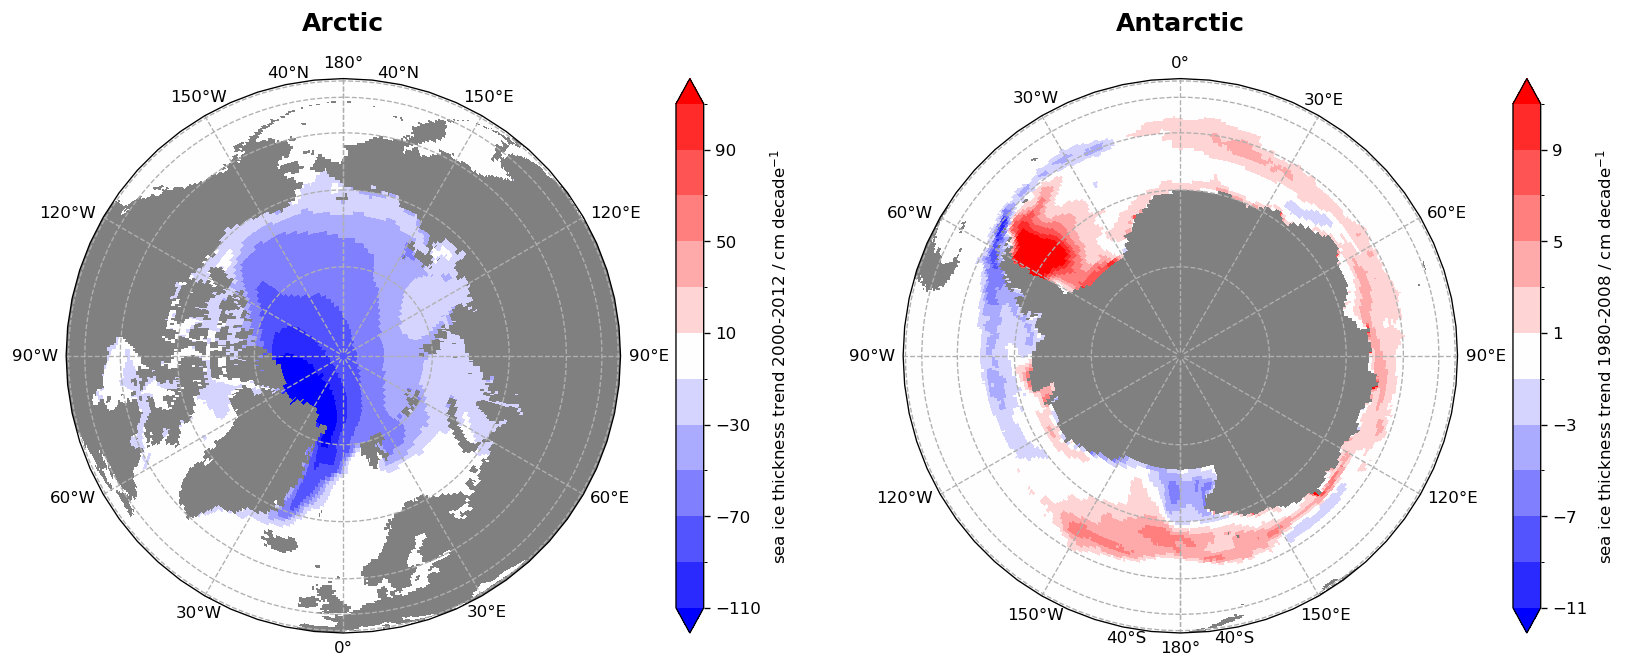

In [11]:
sit_trend_cmap = matplotlib.cm.get_cmap('bwr').copy()
sit_trend_cmap.set_bad(color='grey')

scale_factor = (awi.loc[2012]-awi.loc[2000].mean()) / (awi.loc[2019]-awi.loc[1850:1900].mean()) / 1.2 * 100

fig = plt.figure(figsize=(15,6))
gs = fig.add_gridspec(1,2,wspace=0.5)

ax = [fig.add_subplot(gs[i],projection=crs.NearsidePerspective(central_longitude=0,central_latitude=x,satellite_height=5000000)) for i,x in enumerate([90,-90])]

p=(sit_remap*scale_factor).iicethic.plot(ax=ax[0],transform=crs.PlateCarree(),add_colorbar=False,levels=np.linspace(-110,110,12),cmap=sit_trend_cmap,extend='both')

axins = inset_axes(ax[0], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.1, 0.00, 1, 1),bbox_transform=ax[0].transAxes,borderpad=0)
cbar=plt.colorbar(p,cax=axins)
axins.set_ylabel('sea ice thickness trend 2000-2012 / cm decade$^{-1}$')

scale_factor = (awi.loc[2008]-awi.loc[1980].mean()) / (awi.loc[2019]-awi.loc[1850:1900].mean()) / 2.8 * 100

p=(sit_remap*scale_factor).iicethic.plot(ax=ax[1],transform=crs.PlateCarree(),add_colorbar=False,levels=np.linspace(-11,11,12),cmap=sit_trend_cmap,extend='both')

axins = inset_axes(ax[1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.1, 0.00, 1, 1),bbox_transform=ax[1].transAxes,borderpad=0)
cbar=plt.colorbar(p,cax=axins)
axins.set_ylabel('sea ice thickness trend 1980-2008 / cm decade$^{-1}$')


ax[0].set_title('Arctic',pad=15,fontsize=15,fontweight='bold')
ax[1].set_title('Antarctic',pad=15,fontsize=15,fontweight='bold')

ax[0].gridlines(draw_labels=True,xlocs=np.arange(-180,181,30),linestyle='--')
ax[1].gridlines(draw_labels=True,xlocs=np.arange(-180,181,30),linestyle='--')

fig.dpi=120;

# Check perturbed restarts

In [22]:
definitions.AOPP_BASE_PATH

'/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/'

In [12]:
outdir = "{}output/".format(definitions.AOPP_BASE_PATH)
restartdir = "{}restarts/{}/".format(definitions.AOPP_BASE_PATH,definitions.INIDATE)

lsm = xr.open_dataset('{}source/ancil/mesh_mask.nc'.format(definitions.AOPP_BASE_PATH)).tmask

In [23]:
outdir

'/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/output/'

## 3D restarts

In [44]:
restart_list = glob.glob(restartdir+'*/0001_nrt_*restart.nc*')

In [47]:
def get_restart_and_perturbed(fpath,gzipped=False):
    opa = fpath.split('/')[-2]
    fname = fpath.split('/')[-1]
    expver = fname.split('_')[0]
    year = fname.split('_')[2][:4]
    
    restart = xr.open_dataset(fpath,chunks={'z':1}).expand_dims({'rtype':['original']})
    if gzipped:
        with gzip.open(outdir+'pi-co2/'+expver+'/'+opa+'/'+f'restart/{year}/'+fname+'.gz') as fp:
             pi = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['pi-co2']})
        with gzip.open(outdir+'incr-co2/'+expver+'/'+opa+'/'+f'restart/{year}/'+fname+'.gz') as fp:
              incr = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['incr-co2']})
    else:
        pi = xr.open_dataset(outdir+'pi-co2/'+expver+'/'+opa+'/'+f'restart/{year}/'+fname,chunks={'z':1}).expand_dims({'rtype':['pi-co2']})
        incr = xr.open_dataset(outdir+'incr-co2/'+expver+'/'+opa+'/'+f'restart/{year}/'+fname,chunks={'z':1}).expand_dims({'rtype':['incr-co2']})
    
    ## check 1: rhop deleted:
    print(opa+' variables in original NOT in perturbed:')
    print('pi-co2',set(restart.keys()) ^ pi.keys())
    print('incr-co2',set(restart.keys()) ^ incr.keys(),'\n')
    
    symdiff_vars = list(set(restart.keys()) ^ pi.keys())
    
    return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})

In [ ]:
all_restarts = xr.concat([get_restart_and_perturbed(x,gzipped=True) for x in restart_list],dim='opa')

/tmp/user/27529/ipykernel_329026/412682129.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "z" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  pi = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['pi-co2']})
/tmp/user/27529/ipykernel_329026/412682129.py:12: UserWarning: The specified chunks separate the stored chunks along dimension "z" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  incr = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['incr-co2']})
/tmp/user/27529/ipykernel_329026/412682129.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})


opa0 variables in original NOT in perturbed:
pi-co2 {'rhop'}
incr-co2 {'rhop'} 



/tmp/user/27529/ipykernel_329026/412682129.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "z" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  pi = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['pi-co2']})
/tmp/user/27529/ipykernel_329026/412682129.py:12: UserWarning: The specified chunks separate the stored chunks along dimension "z" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  incr = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['incr-co2']})
/tmp/user/27529/ipykernel_329026/412682129.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})


opa1 variables in original NOT in perturbed:
pi-co2 {'rhop'}
incr-co2 {'rhop'} 



/tmp/user/27529/ipykernel_329026/412682129.py:10: UserWarning: The specified chunks separate the stored chunks along dimension "z" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  pi = xr.open_dataset(fp,chunks={'z':1}).expand_dims({'rtype':['pi-co2']})


In [ ]:
tn_diff_from_original = (all_restarts.sel(rtype='original').tn - all_restarts.tn)
pi_incr_maxdiff = (tn_diff_from_original.sel(rtype='pi-co2') + tn_diff_from_original.sel(rtype='incr-co2')).max(['x','y','t']).to_dataframe()

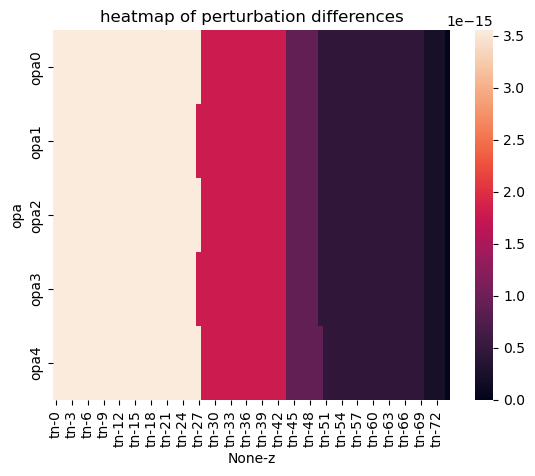

In [ ]:
sn.heatmap(pi_incr_maxdiff.unstack())
plt.title('heatmap of perturbation differences');

In [ ]:
opa_maxdiff = tn_diff_from_original.sel(rtype='pi-co2').diff('opa').max(['x','y','t']).to_dataframe()

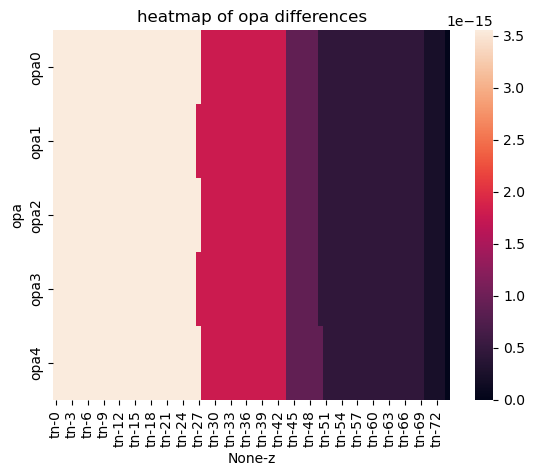

In [ ]:
sn.heatmap(pi_incr_maxdiff.unstack())
plt.title('heatmap of opa differences');

In [ ]:
sn_diff_from_original = (all_restarts.sel(rtype='original').sn - all_restarts.sn)
sn_meandiff = sn_diff_from_original.where(lsm).mean(['x','y','t']).to_dataframe()

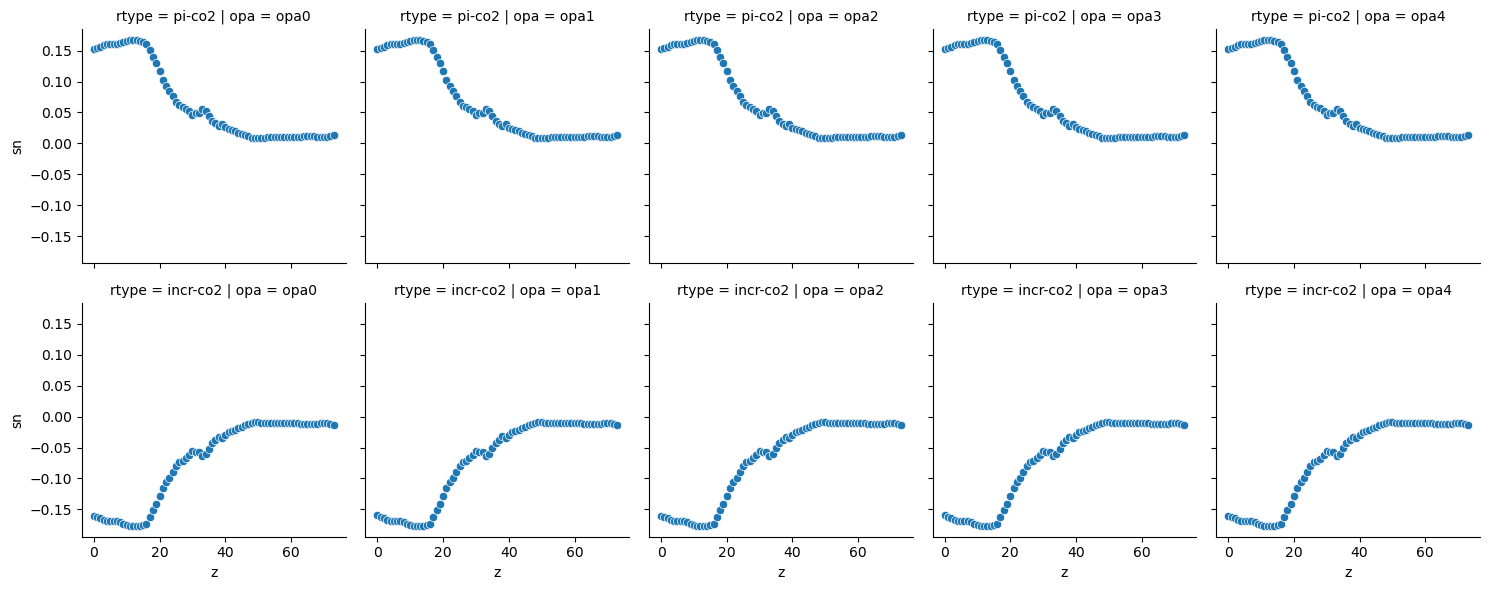

In [ ]:
g=sn.FacetGrid(sn_meandiff.reset_index().query('rtype!="original"'),col='opa',row='rtype')
g.map(sn.scatterplot, 'z' ,'sn');

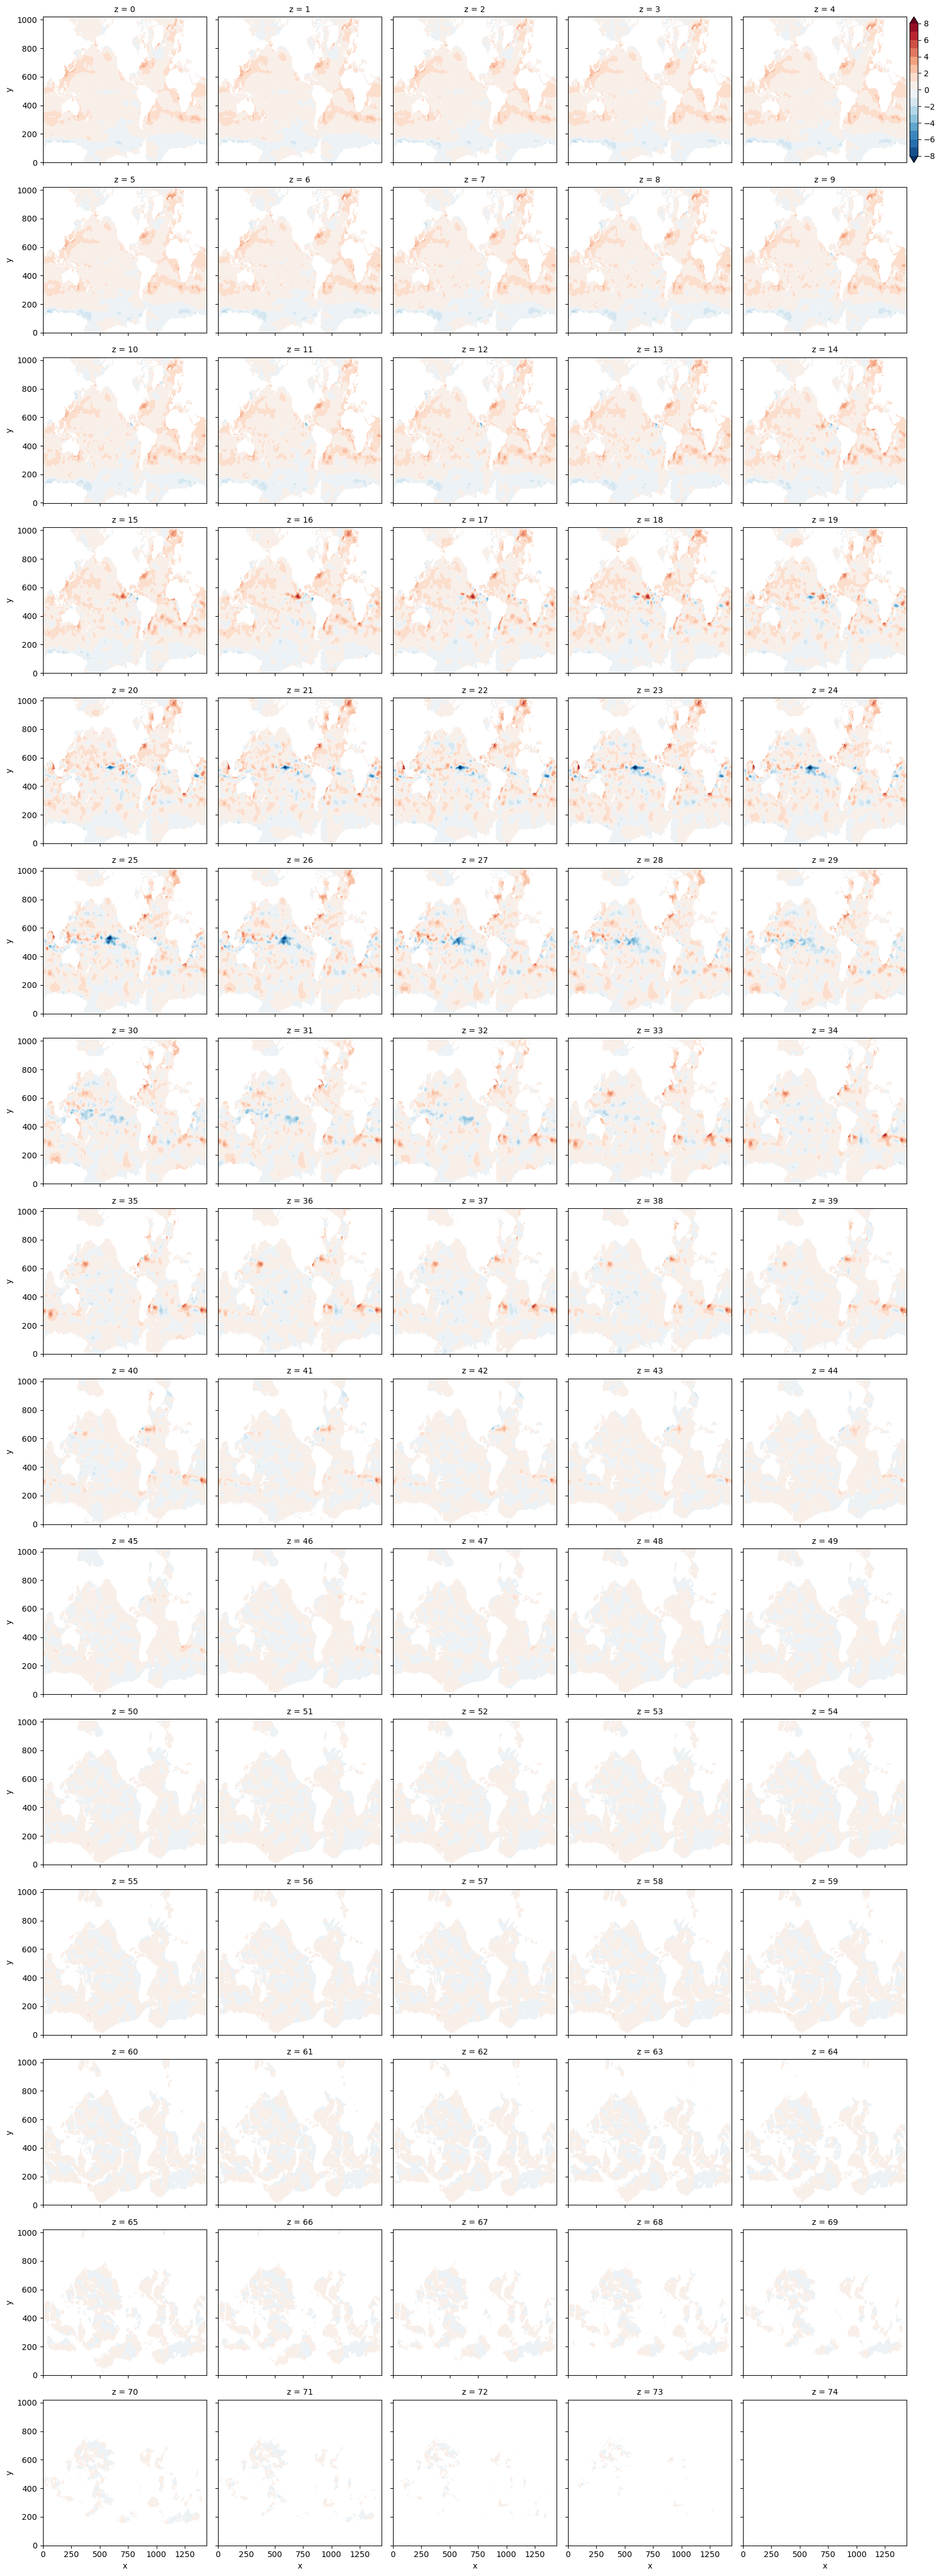

In [ ]:
p=tn_diff_from_original.sel(opa='opa0',rtype='pi-co2').where(lsm).squeeze().plot(levels=np.linspace(-8,8,17),extend='both',col='z',col_wrap=5,cmap='RdBu_r',add_colorbar=False)

axins = inset_axes(p.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p.axes[0,-1].collections[0],cax=axins);

## 2D restarts

In [27]:
restart_list = glob.glob(restartdir+'*/0001_nrt*restart_ice.nc*')

In [28]:
restart_list

['/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/restarts/20210615/opa0/0001_nrt_20210615_000000_restart_ice.nc',
 '/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/restarts/20210615/opa1/0001_nrt_20210615_000000_restart_ice.nc',
 '/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/restarts/20210615/opa2/0001_nrt_20210615_000000_restart_ice.nc',
 '/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/restarts/20210615/opa3/0001_nrt_20210615_000000_restart_ice.nc',
 '/gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/IC_PREP/restarts/20210615/opa4/0001_nrt_20210615_000000_restart_ice.nc']

In [32]:
all_restarts_ice = xr.concat([get_restart_and_perturbed(x) for x in restart_list],dim='opa')

opa0 variables in original NOT in perturbed:
pi-co2 set()
incr-co2 set() 

opa1 variables in original NOT in perturbed:
pi-co2 set()
incr-co2 set() 



/tmp/user/27529/ipykernel_329026/3962433529.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})
/tmp/user/27529/ipykernel_329026/3962433529.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})


opa2 variables in original NOT in perturbed:
pi-co2 set()
incr-co2 set() 

opa3 variables in original NOT in perturbed:
pi-co2 set()
incr-co2 set() 



/tmp/user/27529/ipykernel_329026/3962433529.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})
/tmp/user/27529/ipykernel_329026/3962433529.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})


opa4 variables in original NOT in perturbed:
pi-co2 set()
incr-co2 set() 



/tmp/user/27529/ipykernel_329026/3962433529.py:24: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.concat([restart.drop(symdiff_vars),pi,incr],dim='rtype').expand_dims({'opa':[opa]})


In [33]:
print('max frlead value:')
all_restarts_ice.frld.max(['x','y','t']).to_dataframe().unstack()
# should be one

max frlead value:


frld                
rtype original pi-co2 incr-co2
opa                           
opa0       1.0    1.0      1.0
opa1       1.0    1.0      1.0
opa2       1.0    1.0      1.0
opa3       1.0    1.0      1.0
opa4       1.0    1.0      1.0

In [34]:
print('min frlead value:')
all_restarts_ice.frld.min(['x','y','t']).to_dataframe().unstack()
# should be zero

min frlead value:


frld                
rtype original pi-co2 incr-co2
opa                           
opa0       0.0    0.0      0.0
opa1       0.0    0.0      0.0
opa2       0.0    0.0      0.0
opa3       0.0    0.0      0.0
opa4       0.0    0.0      0.0

In [35]:
print('min hicif value:')
all_restarts_ice.hicif.min(['x','y','t']).to_dataframe().unstack()
# should be zero

min hicif value:


hicif                
rtype original pi-co2 incr-co2
opa                           
opa0       0.0    0.0      0.0
opa1       0.0    0.0      0.0
opa2       0.0    0.0      0.0
opa3       0.0    0.0      0.0
opa4       0.0    0.0      0.0

In [36]:
print('sum of hicif where frld == 1')
(all_restarts_ice.hicif.where(all_restarts_ice.frld==1)**2).sum(['x','y','t']).to_dataframe().unstack()
# should be zero

sum of hicif where frld == 1


hicif                
rtype original pi-co2 incr-co2
opa                           
opa0       0.0    0.0      0.0
opa1       0.0    0.0      0.0
opa2       0.0    0.0      0.0
opa3       0.0    0.0      0.0
opa4       0.0    0.0      0.0

In [37]:
print('mean of frld where hicif == 0')
all_restarts_ice.frld.where(all_restarts_ice.hicif==0).mean(['x','y','t']).to_dataframe().unstack()
# should be one exactly

mean of frld where hicif == 0


frld                
rtype  original pi-co2 incr-co2
opa                            
opa0   0.998853    1.0      1.0
opa1   0.998852    1.0      1.0
opa2   0.998851    1.0      1.0
opa3   0.998852    1.0      1.0
opa4   0.998851    1.0      1.0

/tmp/user/27529/ipykernel_329026/383037672.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  frldcmap = matplotlib.cm.get_cmap('Blues').copy()


/tmp/user/27529/ipykernel_329026/383037672.py:6: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  axins = inset_axes(p.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p.axes[0,-1].transAxes,borderpad=0)
/tmp/user/27529/ipykernel_329026/383037672.py:7: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  cbar=plt.colorbar(p.axes[0,-1].collections[0],cax=axins)
/tmp/user/27529/ipykernel_329026/383037672.py:12: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  axins = inset_axes(p1.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p1.axes[0,-1].transAxes,borderpad=0)
/tmp/user/27529/ipykernel_329026/383037672.py:13: DeprecationWarning: self.axes 

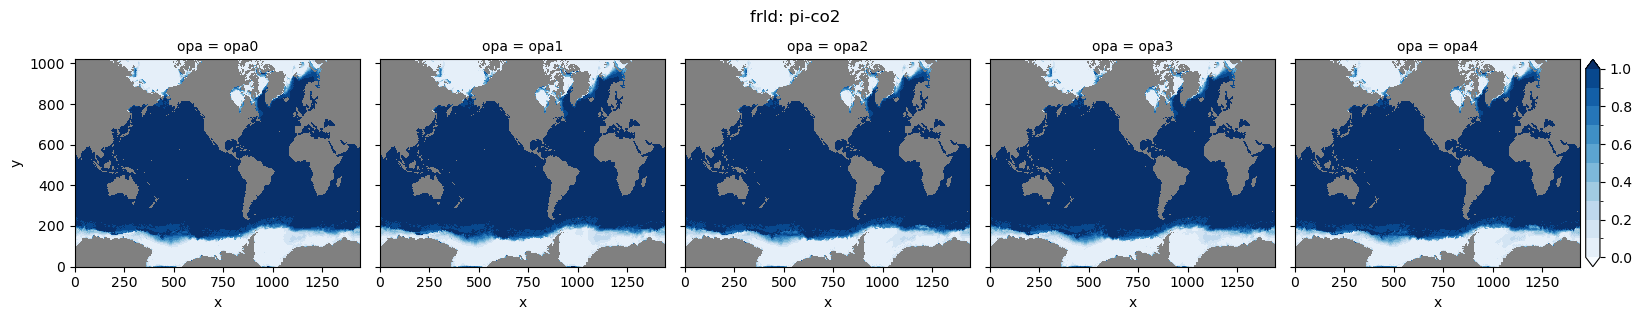

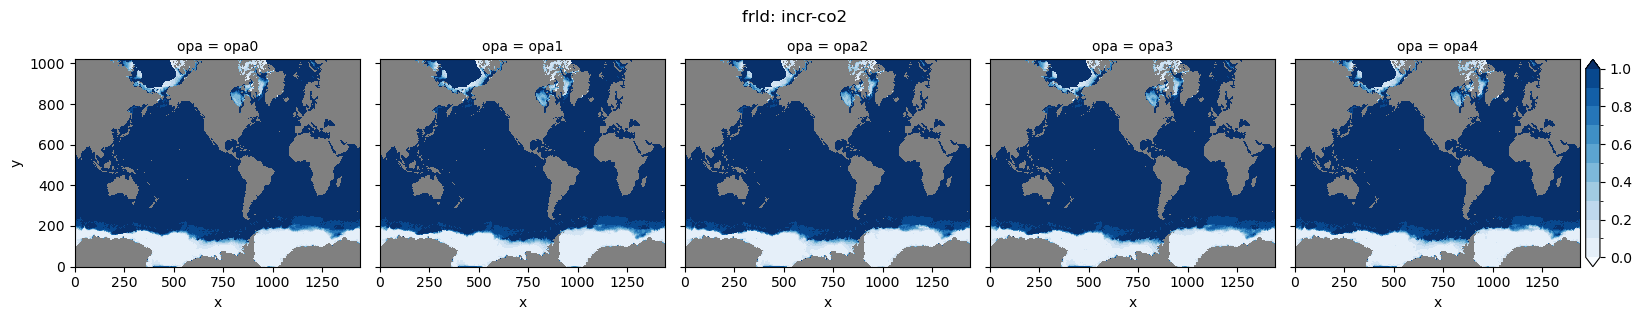

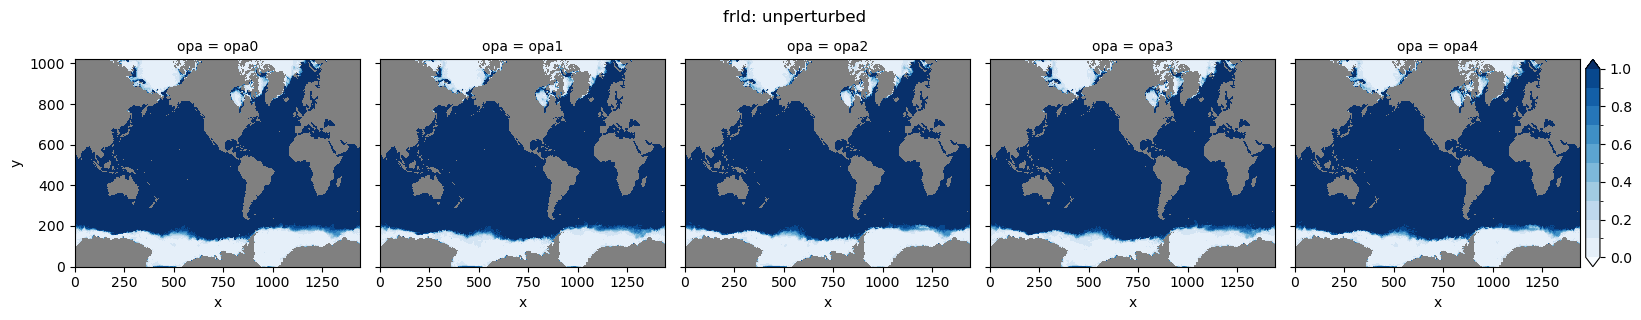

In [38]:
frldcmap = matplotlib.cm.get_cmap('Blues').copy()
frldcmap.set_bad(color='grey')

p=all_restarts_ice.frld.sel(rtype='pi-co2').where(lsm.isel(z=0)).squeeze().plot(levels=np.linspace(0,1,11),extend='both',col='opa',cmap=frldcmap,add_colorbar=False)

axins = inset_axes(p.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p.axes[0,-1].collections[0],cax=axins)
p.fig.suptitle('frld: pi-co2',y=1.05)

p1=all_restarts_ice.frld.sel(rtype='incr-co2').where(lsm.isel(z=0)).squeeze().plot(levels=np.linspace(0,1,11),extend='both',col='opa',cmap=frldcmap,add_colorbar=False)

axins = inset_axes(p1.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p1.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p1.axes[0,-1].collections[0],cax=axins)
p1.fig.suptitle('frld: incr-co2',y=1.05)

p2=all_restarts_ice.frld.sel(rtype='original').where(lsm.isel(z=0)).squeeze().plot(levels=np.linspace(0,1,11),extend='both',col='opa',cmap=frldcmap,add_colorbar=False)

axins = inset_axes(p2.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p2.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p2.axes[0,-1].collections[0],cax=axins)
p2.fig.suptitle('frld: unperturbed',y=1.05);

/tmp/user/27529/ipykernel_329026/22448005.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hicifcmap = matplotlib.cm.get_cmap('BrBG').copy()
/tmp/user/27529/ipykernel_329026/22448005.py:6: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  axins = inset_axes(p.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p.axes[0,-1].transAxes,borderpad=0)
/tmp/user/27529/ipykernel_329026/22448005.py:7: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  cbar=plt.colorbar(p.axes[0,-1].collections[0],cax=axins)
/tmp/user/27529/ipykernel_329026/22448005.py:12: DeprecationWarning: self.axes is deprecated since 2022

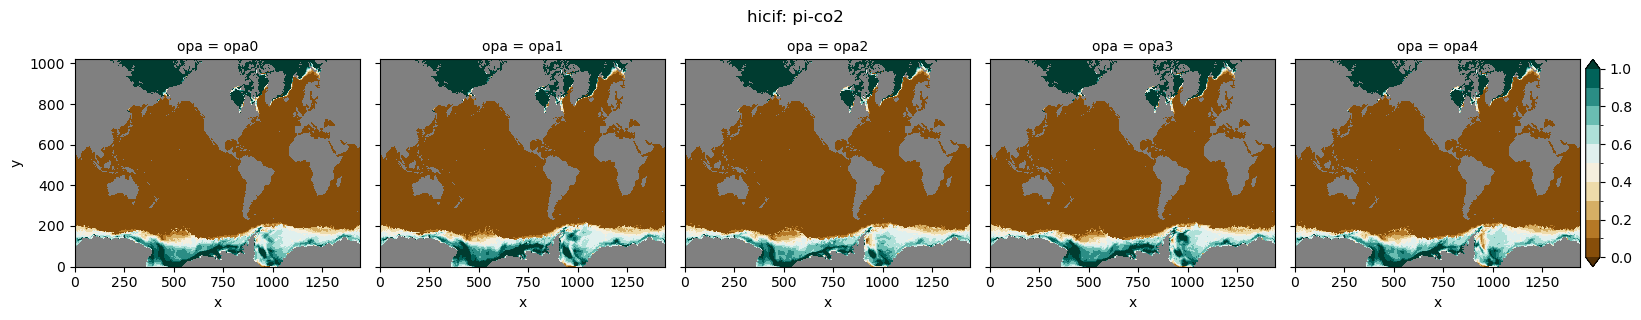

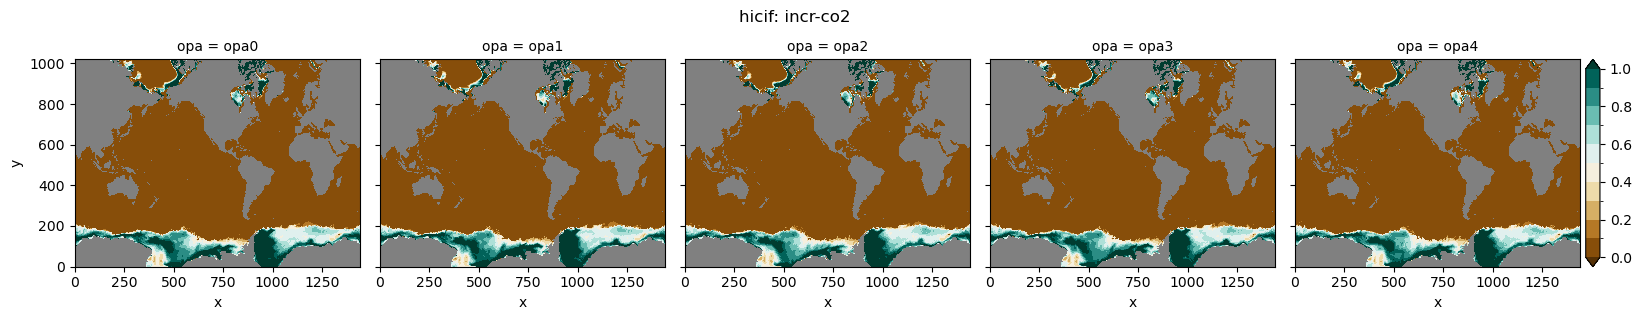

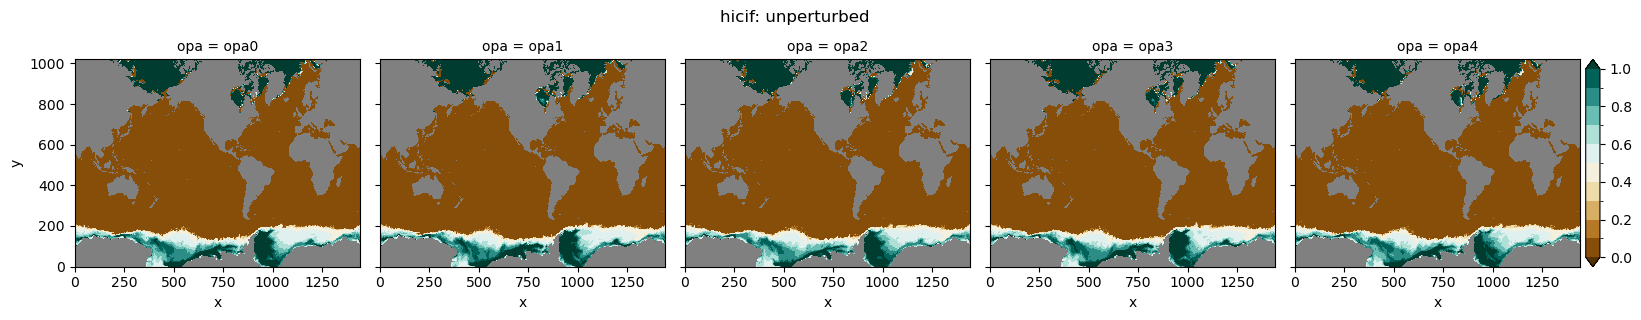

In [39]:
hicifcmap = matplotlib.cm.get_cmap('BrBG').copy()
hicifcmap.set_bad(color='grey')

p=all_restarts_ice.hicif.sel(rtype='pi-co2').where(lsm.isel(z=0)).squeeze().plot(levels=np.linspace(0,1,11),extend='both',col='opa',cmap=hicifcmap,add_colorbar=False)

axins = inset_axes(p.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p.axes[0,-1].collections[0],cax=axins)
p.fig.suptitle('hicif: pi-co2',y=1.05)

p1=all_restarts_ice.hicif.sel(rtype='incr-co2').where(lsm.isel(z=0)).squeeze().plot(levels=np.linspace(0,1,11),extend='both',col='opa',cmap=hicifcmap,add_colorbar=False)

axins = inset_axes(p1.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p1.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p1.axes[0,-1].collections[0],cax=axins)
p1.fig.suptitle('hicif: incr-co2',y=1.05)

p2=all_restarts_ice.hicif.sel(rtype='original').where(lsm.isel(z=0)).squeeze().plot(levels=np.linspace(0,1,11),extend='both',col='opa',cmap=hicifcmap,add_colorbar=False)

axins = inset_axes(p2.axes[0,-1], width="5%",height="100%",loc='lower left',bbox_to_anchor=(1.02, 0.00, 1, 1),bbox_transform=p2.axes[0,-1].transAxes,borderpad=0)
cbar=plt.colorbar(p2.axes[0,-1].collections[0],cax=axins)
p2.fig.suptitle('hicif: unperturbed',y=1.05);

## SST deltas

In [40]:
# pi_sstdelta = xr.open_dataset('{}output/pi-co2/sstdelta/{}.grib'.format(definitions.AOPP_BASE_PATH,definitions.INIDATE))
# incr_sstdelta = xr.open_dataset('{}output/incr-co2/sstdelta/{}.grib'.format(definitions.AOPP_BASE_PATH,definitions.INIDATE))
inidate = '20210627'
pi_sstdelta = xr.open_dataset('{}output/pi-co2/sstdelta/{}.grib'.format(definitions.AOPP_BASE_PATH,inidate))
incr_sstdelta = xr.open_dataset('{}output/incr-co2/sstdelta/{}.grib'.format(definitions.AOPP_BASE_PATH,inidate))

In [41]:
print('max value of pi-co2 + incr-co2 sstdeltas')
(pi_sstdelta + incr_sstdelta).dte.max().values[()]

max value of pi-co2 + incr-co2 sstdeltas


0.0

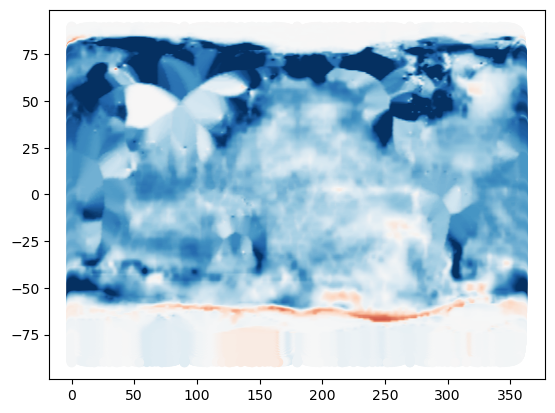

In [42]:
plt.scatter(pi_sstdelta.longitude,pi_sstdelta.latitude,c=pi_sstdelta.dte,cmap='RdBu_r',vmin=-2,vmax=2)

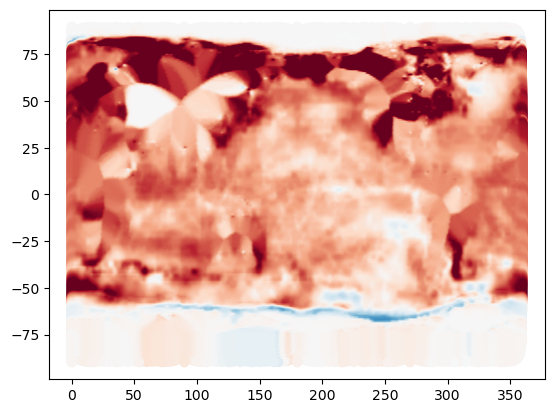

In [43]:
plt.scatter(incr_sstdelta.longitude,incr_sstdelta.latitude,c=incr_sstdelta.dte,cmap='RdBu_r',vmin=-2,vmax=2)